# Plotting NetCDF Maps with Xarray & Cartopy - JP Math Review 2026

**Goal:** open a real ocean dataset (GEBCO seafloor bathymetry), and make a proper map of the seafloor around Woods Hole.

Thigs we will learn:
1. open a `.nc` (NetCDF) file with **xarray**
2. understand a `Dataset` → `DataArray` → dims / coords
3. make a quick plot with one line
4. select a region and subsample
5. draw a map with **cartopy** (coastlines, gridlines, a colorbar, a marker)

Files needed: `gebco_2026_NorthAtlantic.nc` (or your own selected region)

## 0. Import the tools
Run this first. If any import fails, your `math-review` environment isn't active (go back to your terminal and activate)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs          # crs = coordinate reference systems (map projections)
import cartopy.feature as cfeature  # coastlines, land, etc.
import cmocean                      # pretty ocean colormaps

plt.rcParams['figure.figsize'] = (10, 8)

## 1. Open the file

A NetCDF file is the standard container for gridded science data (ocean, atmosphere, climate).
`xr.open_dataset` reads it into a **Dataset** — It's like labeled box of arrays.

In [2]:
ds = xr.open_dataset('gebco_2026_NorthAtlantic.nc')
ds

<xarray.Dataset> Size: 202MB
Dimensions:    (lat: 6000, lon: 8400)
Coordinates:
  * lat        (lat) float64 48kB 30.0 30.01 30.01 30.01 ... 54.99 54.99 55.0
  * lon        (lon) float64 67kB -75.0 -74.99 -74.99 ... -40.01 -40.01 -40.0
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) float32 202MB ...
Attributes: (12/37)
    comment:                         The data in the GEBCO_2026 Grid should n...
    Conventions:                     CF-1.6, ACDD-1.3
    creator_email:                   gdacc@seabed2030.org
    creator_name:                    GEBCO through the Nippon Foundation-GEBC...
    creator_type:                    International organisation
    creator_url:                     https://www.gebco.net
    ...                              ...
    project:                         Nippon Foundation - GEBCO Seabed2030 Pro...
    references:                      DOI: 10.5285/4f68d5c7-45eb-f999-e063-708...
    source:                          The GEBCO_2026 Grid is the 2026 release ...
    summary:                         The GEBCO_2026 Grid is a continuous, glo...
    title:                           The GEBCO_2026 Grid - a continuous terra...
    GDAL:                            GDAL 3.10.3, released 2025/04/01

Read the output above. You should see:
- **Dimensions:** `lat: 6000, lon: 8400`  → the grid is 6000 × 8400 points
- **Coordinates:** `lat`, `lon`  → the actual latitude/longitude values
- **Data variables:** `elevation`  → seafloor/land height in metres (negative = below sea level)

Pull out the one variable we care about. A single variable is a **DataArray**:

In [3]:
bathy = ds['elevation']
bathy

<xarray.DataArray 'elevation' (lat: 6000, lon: 8400)> Size: 202MB
[50400000 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 48kB 30.0 30.01 30.01 30.01 ... 54.99 54.99 55.0
  * lon      (lon) float64 67kB -75.0 -74.99 -74.99 ... -40.01 -40.01 -40.0
Attributes:
    long_name:           Elevation relative to sea level
    grid_mapping:        crs
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_uom_name:        Metres
    sdn_uom_urn:         SDN:P06::ULAA
    standard_name:       height_above_mean_sea_level
    units:               m

A few ways to inspect it — dimensions, shape, and the range of the coordinates:

In [4]:
print('dims :', bathy.dims)
print('shape:', bathy.shape)
print('lat  :', float(ds.lat.min()), 'to', float(ds.lat.max()))
print('lon  :', float(ds.lon.min()), 'to', float(ds.lon.max()))
print('depth:', float(bathy.min()), 'to', float(bathy.max()), 'm')

dims : ('lat', 'lon')
shape: (6000, 8400)
lat  : 30.00208333333333 to 54.99791666666667
lon  : -74.99791666666667 to -40.002083333333324
depth: -6485.0 to 1861.0 m


## 2. The one-line plot

xarray knows the axes are lat/lon, so `.plot()` just works. Great for a quick look
(no map projection yet — just the raw grid).

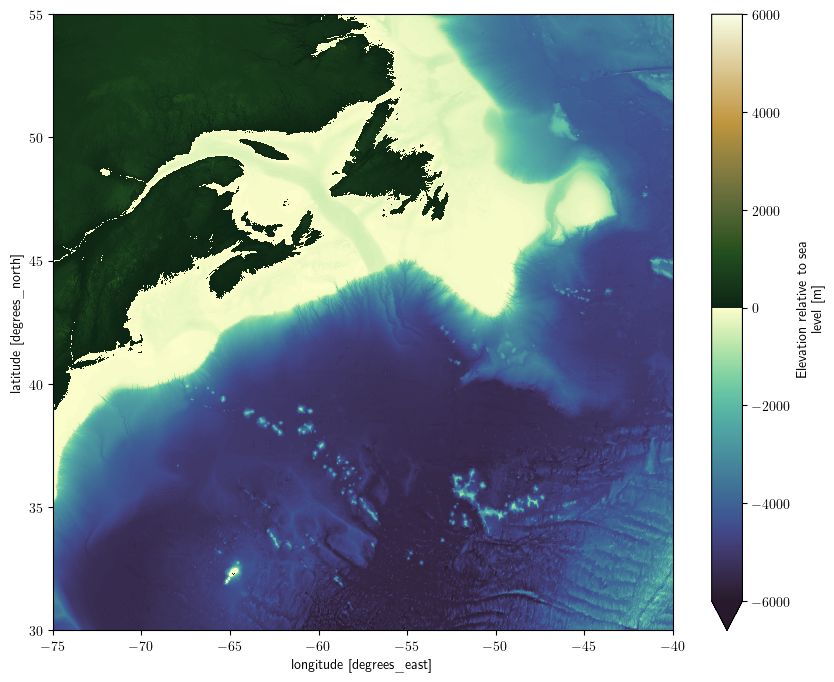

In [5]:
bathy.plot(cmap=cmocean.cm.topo, vmin=-6000, vmax=6000)
plt.show()

## 3. Subsample — why 8400×6000 is too much

That grid is 50 **million** points. Plotting all of them is slow. `isel` = *index select*: take every ## points in each direction.

In [6]:
small = bathy.isel(lat=slice(None, None, 10), lon=slice(None, None, 10))
print('was  :', bathy.shape)
print('now  :', small.shape)

was  : (6000, 8400)
now  : (600, 840)


## 4. Select a region with `.sel`

`isel` selects by *position*; `.sel` selects by *value* (actual degrees).
Let's zoom to the Gulf of Maine / Woods Hole area.

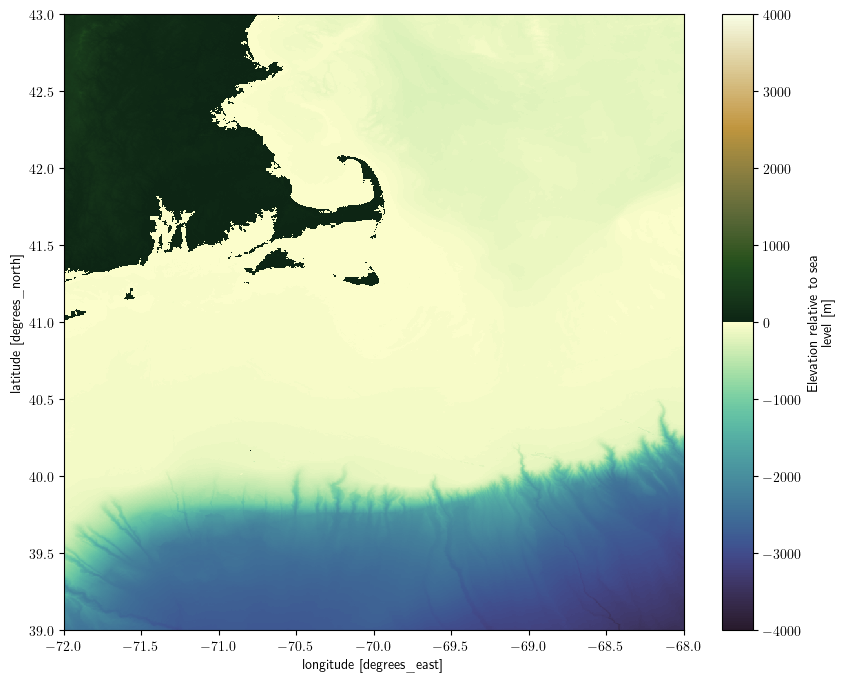

In [14]:
region = bathy.sel(lat=slice(39, 43), lon=slice(-72, -68))
region.plot(cmap=cmocean.cm.topo, vmin=-4000, vmax=4000);

### 4a. Select only seafloor

In [15]:
floor = region.where(region <= 0)

## 5. A real map with Cartopy

Two ideas that trip everyone up at first:
- **projection** = how the map is drawn on your screen (`ccrs.PlateCarree()` = plain lon/lat)
- **transform** = what coordinate system *your data* is in (GEBCO is lon/lat = `PlateCarree`)

You set the axes' projection once, and tell every plotting call the data's transform.

Text(0.5, 1.0, 'GEBCO 2026 Bathymetry — North Atlantic')

/opt/anaconda3/lib/python3.12/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


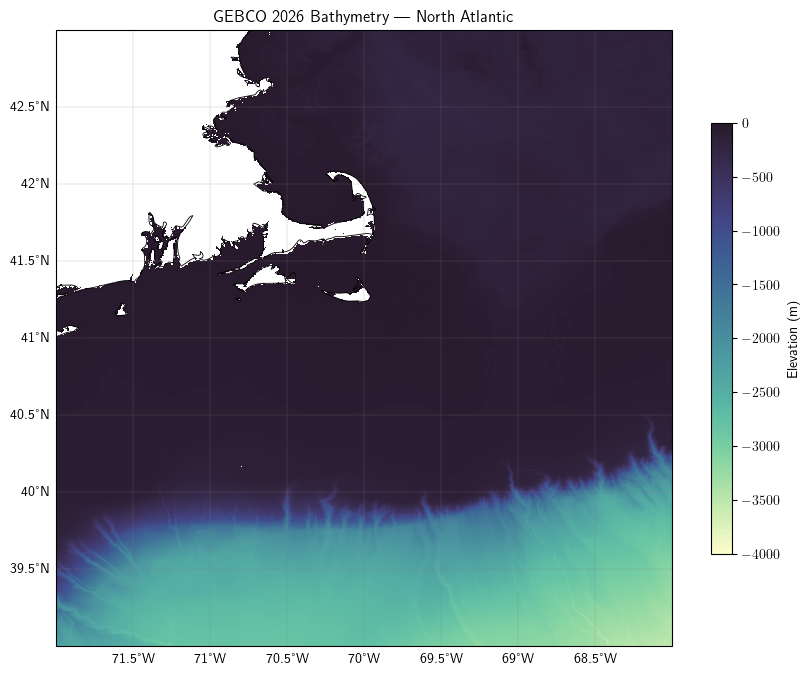

In [16]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

floor.plot.pcolormesh(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.deep, vmin=-4000, vmax=0,
    cbar_kwargs={'label': 'Elevation (m)', 'shrink': 0.7},
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
# ax.add_feature(cfeature.)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
ax.set_title('GEBCO 2026 Bathymetry — North Atlantic')


## 6. Make the figure pretier and mark Woods Hole

Add a marker + label and impove layout. Note we pass `transform=ccrs.PlateCarree()` again so cartopy
knows the point is given in lon/lat.

/opt/anaconda3/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: The following kwargs were not used by contour: 'linestayles'
  result = super().contour(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: The following kwargs were not used by contour: 'linestayles'
  result = super().contour(*args, **kwargs)


Text(0.5, 1.0, 'GEBCO 2026 Bathymetry — North Atlantic')

/opt/anaconda3/lib/python3.12/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


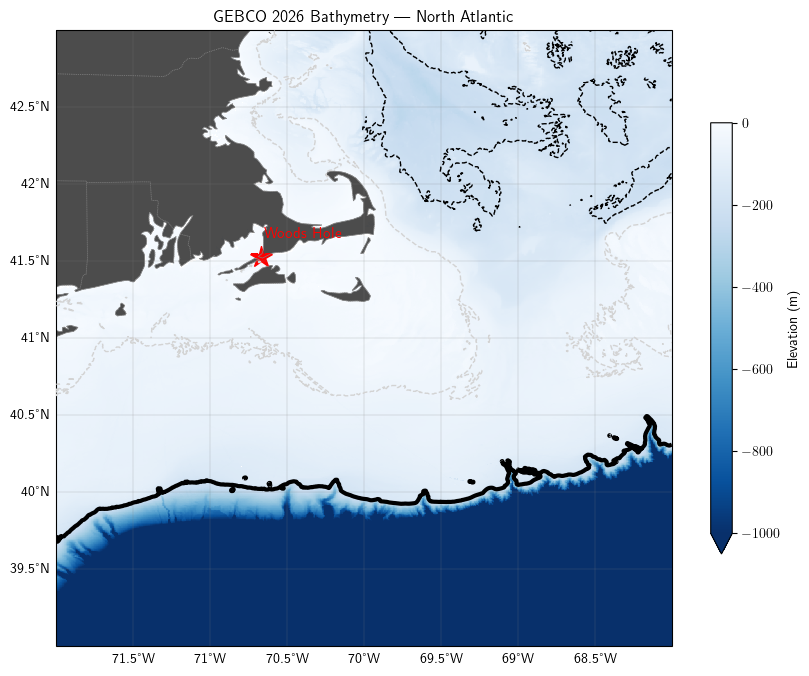

In [41]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

floor.plot.pcolormesh(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap="Blues_r", vmin=-1000, vmax=0,
    cbar_kwargs={'label': 'Elevation (m)', 'shrink': 0.7},
)

# Add contours
ax.contour(floor.lon, floor.lat, floor, levels = [-50], linestayles='--', linewidths=1, colors='lightgrey', zorder=3)
ax.contour(floor.lon, floor.lat, floor, levels = [-200], linestayles='solid', linewidths=1, colors='k', zorder=3)

# Improve 200m isobath
south = floor.sel(lat=slice(None, 41.5))     
ax.contour(south.lon, south.lat, south, levels=[-200], colors='k', linewidths=3, linestyles='-', zorder=3)

# Add features
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="k", alpha=0.7, zorder=1)
ax.add_feature(cfeature.STATES, linestyle=":", zorder=1, linewidth=0.5, edgecolor="gray")
ax.coastlines(resolution="10m", linewidths=0.5, color="gray", zorder=2.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.top_labels = False; gl.right_labels = False

# Woods Hole, MA
ax.plot(-70.67, 41.53, marker='*', color='red', markersize=16,
        transform=ccrs.PlateCarree())
ax.text(-70.65, 41.65, 'Woods Hole', transform=ccrs.PlateCarree(), fontsize=11, color='r')

ax.set_title('GEBCO 2026 Bathymetry — North Atlantic')
# fig.savefig('bathymetry_map.png', dpi=150, bbox_inches='tight')  # uncomment to save

## 7. Bonus: a depth transect (back to 1-D)

Grab a single latitude line and plot depth vs longitude — a slice through the seafloor.
`method='nearest'` picks the closest grid row to 41.5°N.

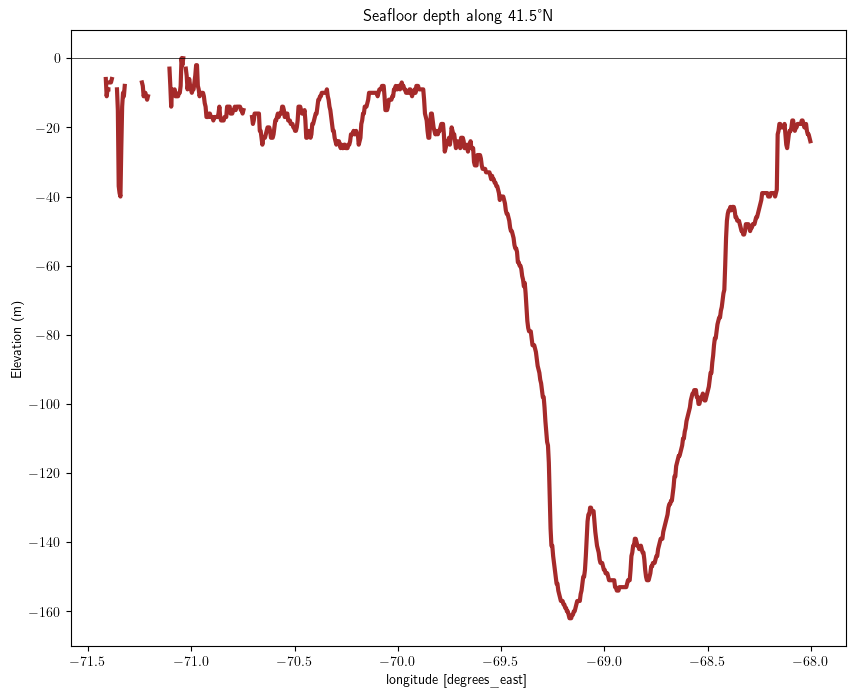

In [34]:
transect = floor.sel(lat=41.5, method='nearest')
transect.plot(c='brown', lw=3)
plt.axhline(0, color='k', lw=0.5)       # sea level
plt.title('Seafloor depth along 41.5°N')
plt.ylabel('Elevation (m)')
plt.show()

## Your turn 🎯

Copy a cell above and try:
1. Re-center the map on a place you care about (change the `.sel` ranges).
2. Swap the colormap: `cmocean.cm.dense`, or matplotlib's `'terrain'`.
3. Draw a transect along a **longitude** instead of a latitude.
4. Add a second marker for another city (look up its lon/lat).